# Importation des données

In [ ]:
#! mkdir ~/.kaggle
#! cp kaggle.json ~/.kaggle/
#! chmod 600 ~/.kaggle/kaggle.json

In [ ]:
#! kaggle kernels pull meddhiaeddinedabbech/fraud-detection-in-insurance-claims

In [ ]:
#! kaggle datasets download -d meddhiaeddinedabbech/fraud-detection-in-insurance-claims

La première cellule s'éxécute normalement.

Le bouton "Copy API command" du dataset kaggle donne accès à un fichier .ipynb (python notebook)

J'ai essayé de changer la commande pour télécharger le dataset mais comme c'est un dataset privé, l'éxécution donne lieu à une erreur (forbidden)

J'ai donc téléchargé manuellement le dataset qui est en pièce jointe de l'e-mail.

In [ ]:
import pandas as pd
df = pd.read_csv('insurance_claims.csv')

# Exploration des données

## Exploration préliminaire

In [ ]:
df.head(10)

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN
5,256,39,104594,2006-10-12,OH,250/500,1000,1351.10,0,478456,...,NO,64100,6410,6410,51280,Saab,95,2003,Y,NaN
6,137,34,413978,2000-06-04,IN,250/500,1000,1333.35,0,441716,...,?,78650,21450,7150,50050,Nissan,Pathfinder,2012,N,NaN
7,165,37,429027,1990-02-03,IL,100/300,1000,1137.03,0,603195,...,YES,51590,9380,9380,32830,Audi,A5,2015,N,NaN
8,27,33,485665,1997-02-05,IL,100/300,500,1442.99,0,601734,...,YES,27700,2770,2770,22160,Toyota,Camry,2012,N,NaN
9,212,42,636550,2011-07-25,IL,100/300,500,1315.68,0,600983,...,?,42300,4700,4700,32900,Saab,92x,1996,N,NaN


**Création d'une fonction pour un résumé de données plus complet**

Je crée dans la cellule suivante une fonction info() à laquelle je donne en entrée un DataFrame et qui me donne en sortie un DataFrame qui contient les mêmes données que la méthode df.info() (donc une colonne avec le nom des colonnes du DataFrame en entrée, le nombre de valeurs non-nulles de chaque colonne et leur type) en plus d'une colonne pour le nombre de valeurs uniques de chaque colonne.

In [ ]:
def info(df):
  d = df.dtypes
  df_details = pd.DataFrame(data = {
      'columns': d.keys(),
      'non-null_values' : [len(df[df[elm[0]].notnull()]) for elm in d.items()],
      'types': d.values,
      'unique_values' : [len(df[elm[0]].unique()) for elm in d.items()]
  })
  return df_details

info(df)

,columns,non-null_values,types,unique_values
0,months_as_customer,1000,int64,391
1,age,1000,int64,46
2,policy_number,1000,int64,1000
3,policy_bind_date,1000,object,951
4,policy_state,1000,object,3
5,policy_csl,1000,object,3
6,policy_deductable,1000,int64,3
7,policy_annual_premium,1000,float64,991
8,umbrella_limit,1000,int64,11
9,insured_zip,1000,int64,995


In [ ]:
df.describe()

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,_c39
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,0.0
mean,203.954000,38.948000,546238.648000,1136.000000,1256.406150,1.101000e+06,501214.488000,25126.100000,-26793.700000,11.644000,1.83900,0.992000,1.487000,52761.94000,7433.420000,7399.570000,37928.950000,2005.103000,NaN
std,115.113174,9.140287,257063.005276,611.864673,244.167395,2.297407e+06,71701.610941,27872.187708,28104.096686,6.951373,1.01888,0.820127,1.111335,26401.53319,4880.951853,4824.726179,18886.252893,6.015861,NaN
min,0.000000,19.000000,100804.000000,500.000000,433.330000,-1.000000e+06,430104.000000,0.000000,-111100.000000,0.000000,1.00000,0.000000,0.000000,100.00000,0.000000,0.000000,70.000000,1995.000000,NaN
25%,115.750000,32.000000,335980.250000,500.000000,1089.607500,0.000000e+00,448404.500000,0.000000,-51500.000000,6.000000,1.00000,0.000000,1.000000,41812.50000,4295.000000,4445.000000,30292.500000,2000.000000,NaN
50%,199.500000,38.000000,533135.000000,1000.000000,1257.200000,0.000000e+00,466445.500000,0.000000,-23250.000000,12.000000,1.00000,1.000000,1.000000,58055.00000,6775.000000,6750.000000,42100.000000,2005.000000,NaN
75%,276.250000,44.000000,759099.750000,2000.000000,1415.695000,0.000000e+00,603251.000000,51025.000000,0.000000,17.000000,3.00000,2.000000,2.000000,70592.50000,11305.000000,10885.000000,50822.500000,2010.000000,NaN
max,479.000000,64.000000,999435.000000,2000.000000,2047.590000,1.000000e+07,620962.000000,100500.000000,0.000000,23.000000,4.00000,2.000000,3.000000,114920.00000,21450.000000,23670.000000,79560.000000,2015.000000,NaN


/usr/local/lib/python3.10/dist-packages/seaborn/categorical.py:3544: UserWarning: 5.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


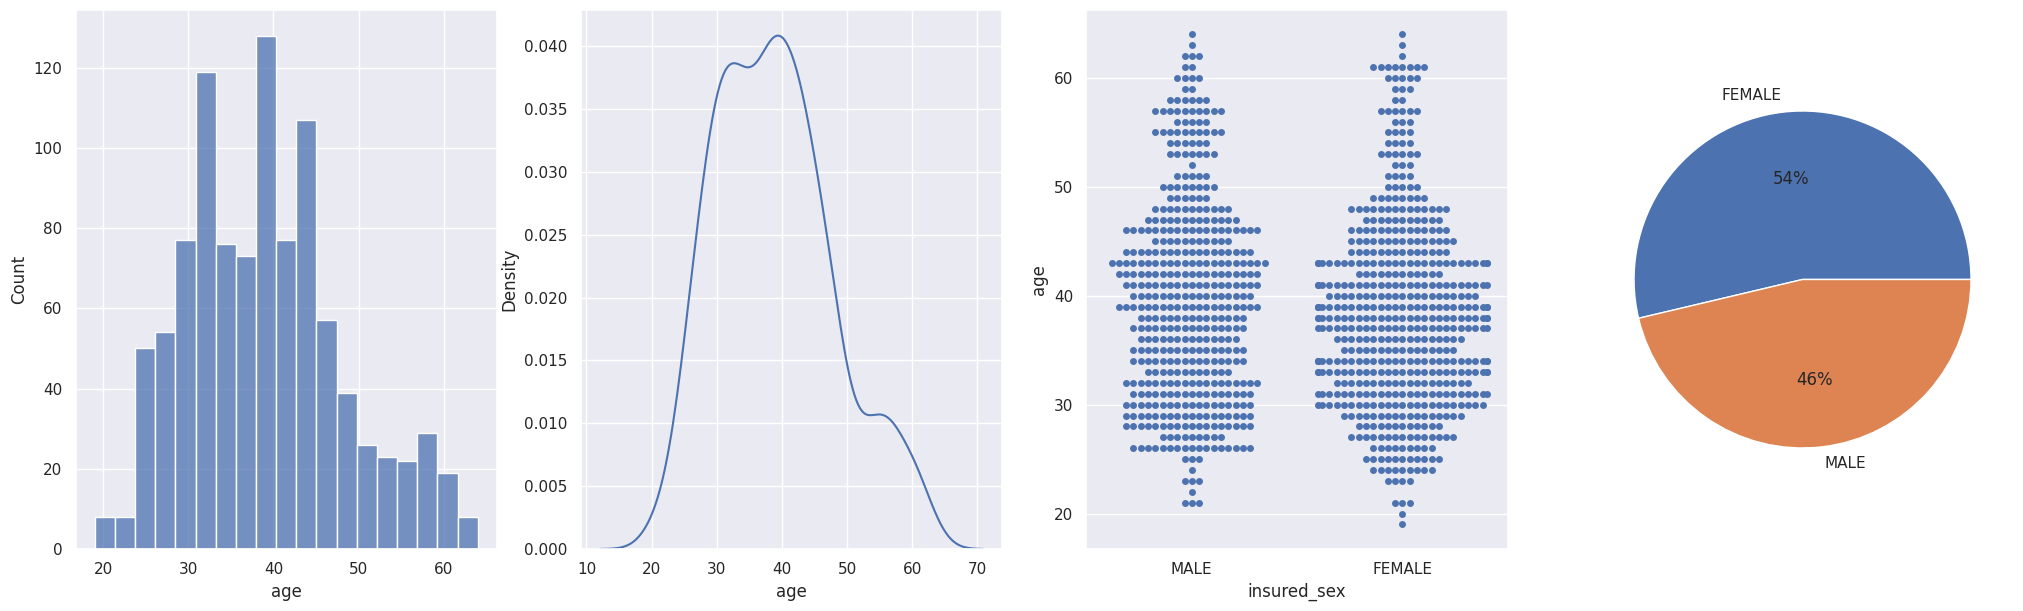

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
fig, axs = plt.subplots(1,4,figsize=(25,7))
sns.histplot(data = df, x='age', ax=axs[0])
sns.kdeplot(data = df, x='age', ax=axs[1]) #L'age suit une distribution gaussienne
sns.swarmplot(data=df,y='age',x="insured_sex", ax=axs[2])
axs[3].pie(df['insured_sex'].value_counts(), labels = df['insured_sex'].value_counts().keys(), autopct='%.0f%%')
fig.show()

## Visualisation des données qualitatives

In [ ]:
info(df)[info(df)['types']=='object']

,columns,non-null_values,types,unique_values
3,policy_bind_date,1000,object,951
4,policy_state,1000,object,3
5,policy_csl,1000,object,3
10,insured_sex,1000,object,2
11,insured_education_level,1000,object,7
12,insured_occupation,1000,object,14
13,insured_hobbies,1000,object,20
14,insured_relationship,1000,object,6
17,incident_date,1000,object,60
18,incident_type,1000,object,4


In [ ]:
df['fraud_reported'].value_counts()

N    753
Y    247
Name: fraud_reported, dtype: int64

In [ ]:
df['fraud_reported'] = [1 if x == 'Y' else 0 for x in df['fraud_reported']]
df['fraud_reported'].value_counts()

0    753
1    247
Name: fraud_reported, dtype: int64

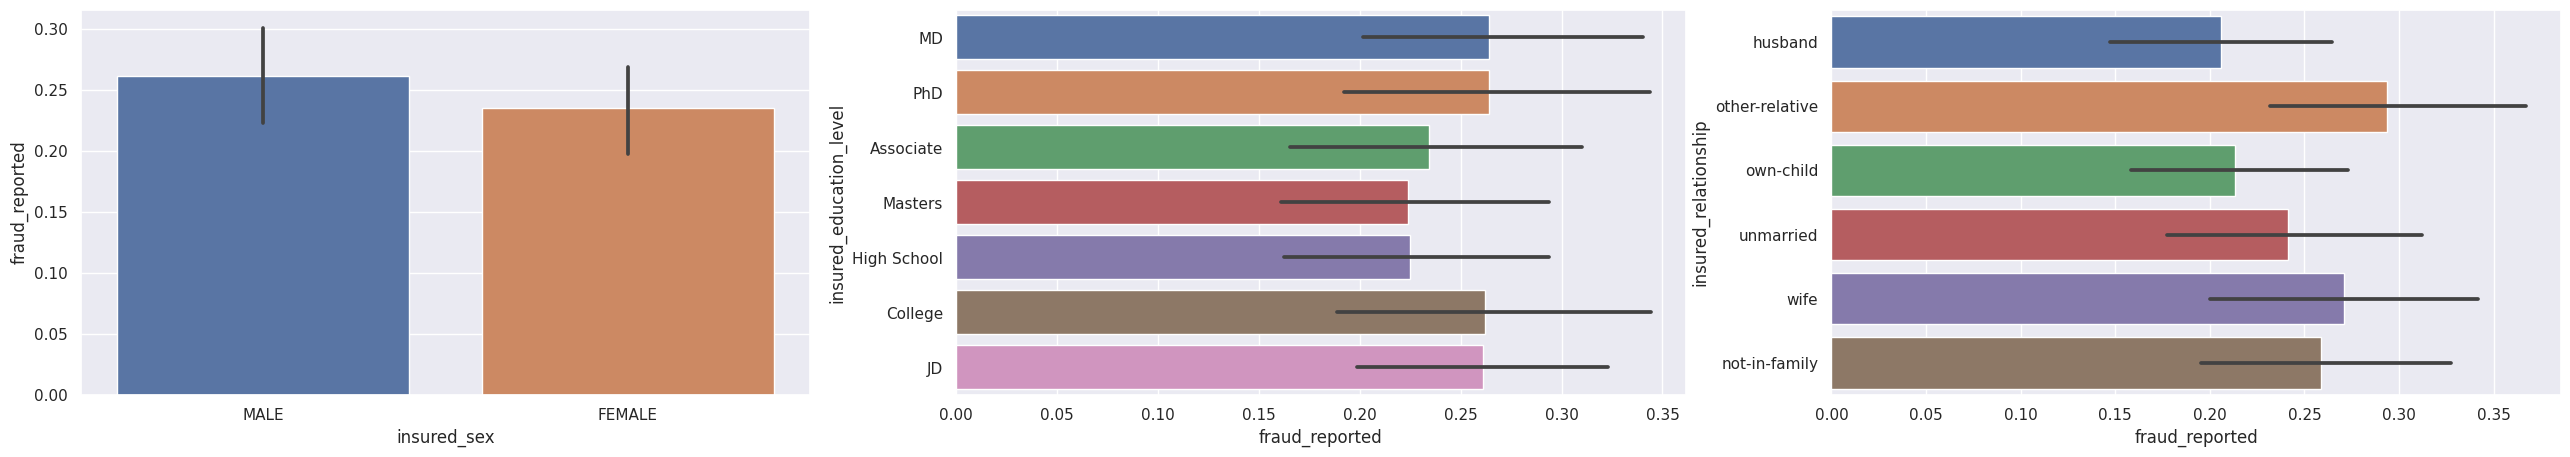

In [ ]:
fig, axs = plt.subplots(1,3,figsize=(32,5))
sns.barplot(data = df,x='insured_sex',y='fraud_reported', ax=axs[0])
sns.barplot(data = df,x='fraud_reported',y='insured_education_level', ax=axs[1])
sns.barplot(data = df,x='fraud_reported',y='insured_relationship', ax=axs[2])
fig.show()

**Interprétation**
*   On remarque dans le premier graphique en partant de la gauche que la propotion de fraude chez les femmes ainsi que les hommes se rapproche de 25%.
*   On remarque dans le deuxième graphique qu'il y a autour de 26% de fraude chez les MD, PhD, College et JD et autour de 22% pour les Associate, Masters et High School.
*   On remarque dans le dernier graphique entre 20% et 30% de fraude pour tous les éléments.

Ce qui indique que l'influence de ces features est négligeable lors de la prédiction d'une fraude.

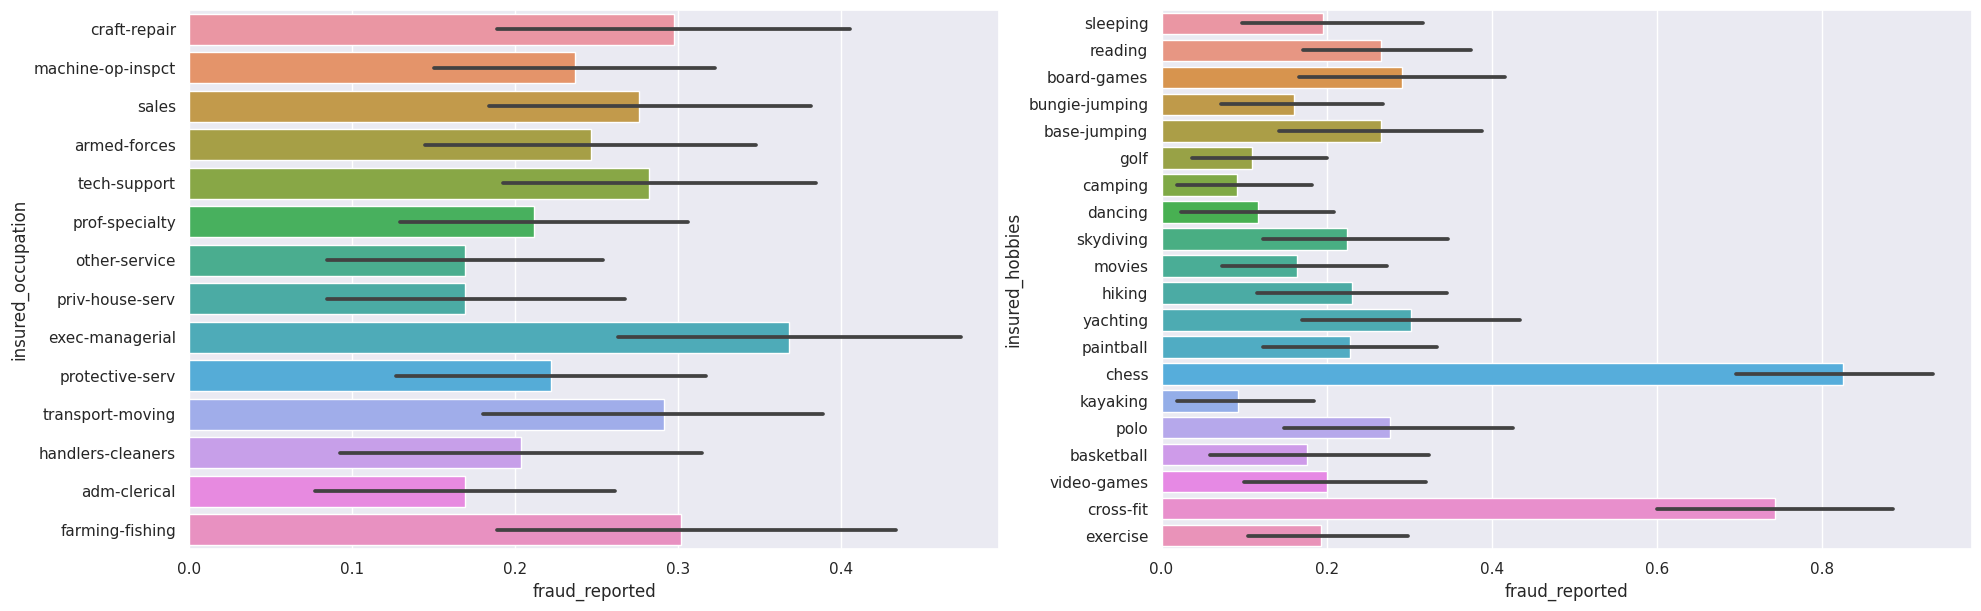

In [ ]:
fig, axs = plt.subplots(1,2,figsize=(23,7))
sns.barplot(data = df,x='fraud_reported',y='insured_occupation', ax=axs[0])
sns.barplot(data = df,x='fraud_reported',y='insured_hobbies', ax=axs[1])
fig.show()

**Interprétation**
*   On remarque dans le premier graphique en partant de la gauche que la propotion de fraude chez les exec-managerial à 37% est plus élevée que pour les autres fonctions qui sont entre 15% et 30%.
*   On remarque dans le deuxième graphique qu'il y a près de 75% de fraude chez les assurés qui ont pour hobbie le cross-fit et plus de 80% pour ceux qui aiment le jeu d'échecs, pour le reste des hobbies le taux de fraude ne dépasse pas les 30%.

Ce qui indique que l'occupation de l'assuré n'a pas grande influence sur la prédiction que ce dernier frauderait. Par contre, l'hobbie de l'assuré est plus susceptible d'influencer la prédiction d'une fraude.

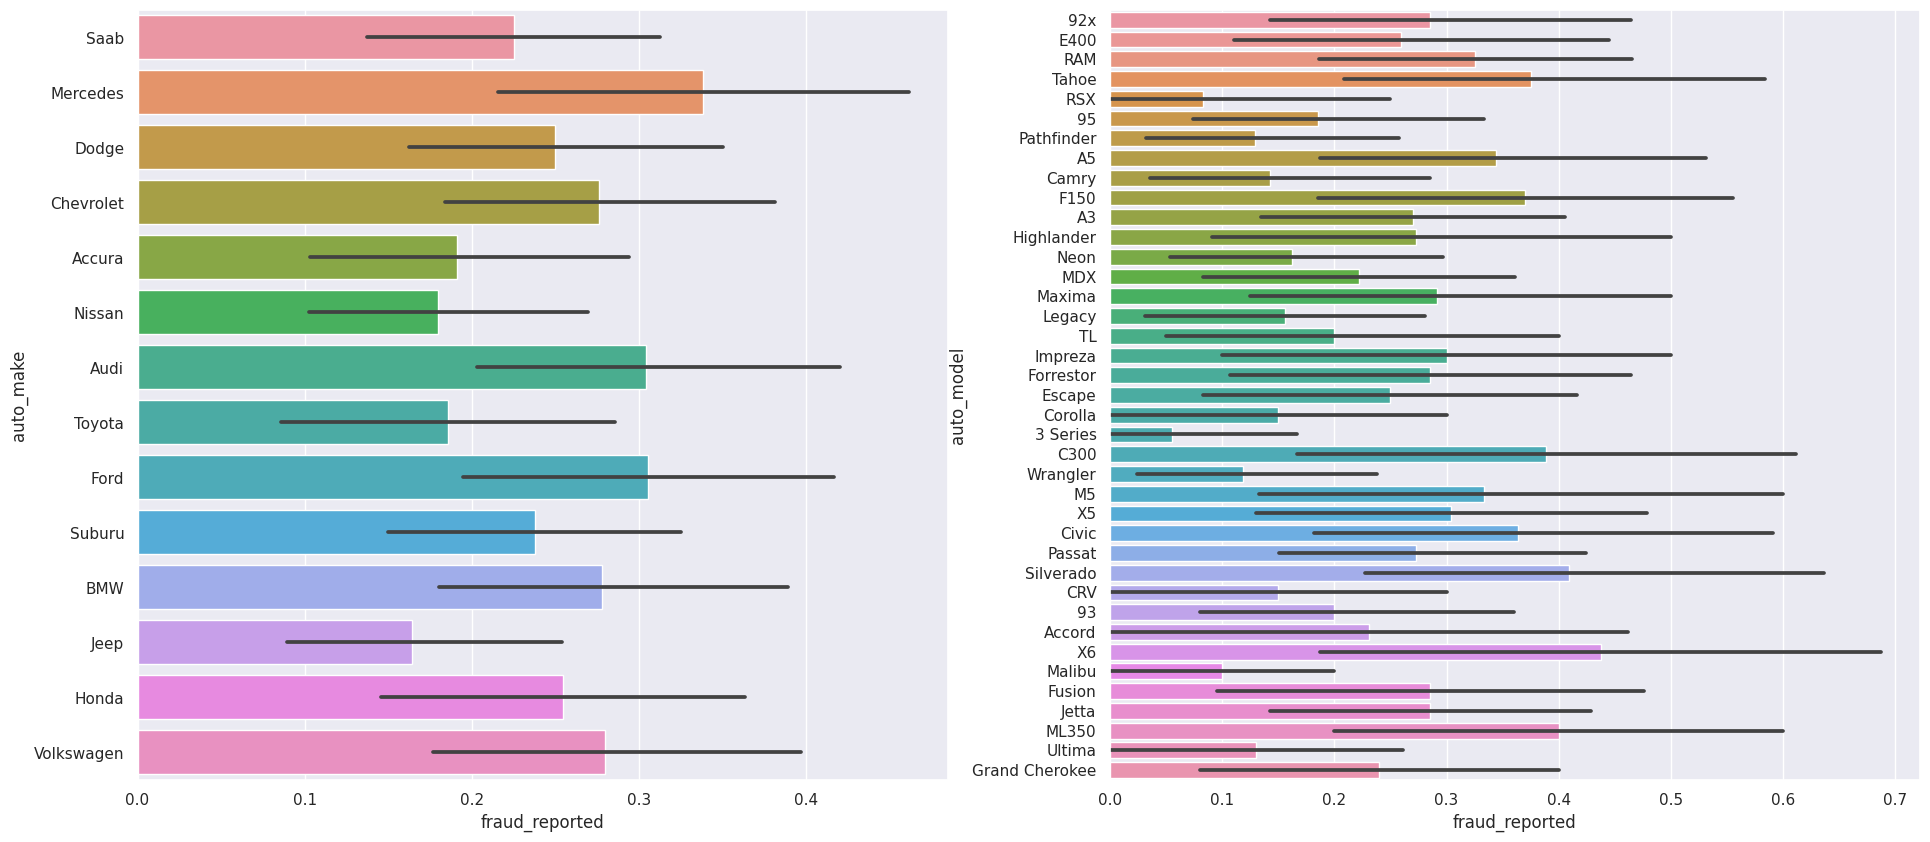

In [ ]:
fig, axs = plt.subplots(1,2,figsize=(23,10))
sns.barplot(data = df,x='fraud_reported',y='auto_make', ax=axs[0])
sns.barplot(data = df,x='fraud_reported',y='auto_model', ax=axs[1])
fig.show()

**Interprétation**
*   On remarque dans le premier graphique en partant de la gauche que la propotion de fraude pour les assurés ayant des véhicules de la marque Mercedes, Aui et Ford est au-delà des 30%, alors que pour les autres marques le taux de fraude est entre 15% et 29%.
*   On remarque dans le deuxième graphique qu'il n'y que pour les modèles Silverado, X6 et ML350 que le taux de fraude est supérieur ou égal à 40%.

Ce qui indique que l'influence de ces features est négligeable lors de la prédiction d'une fraude.

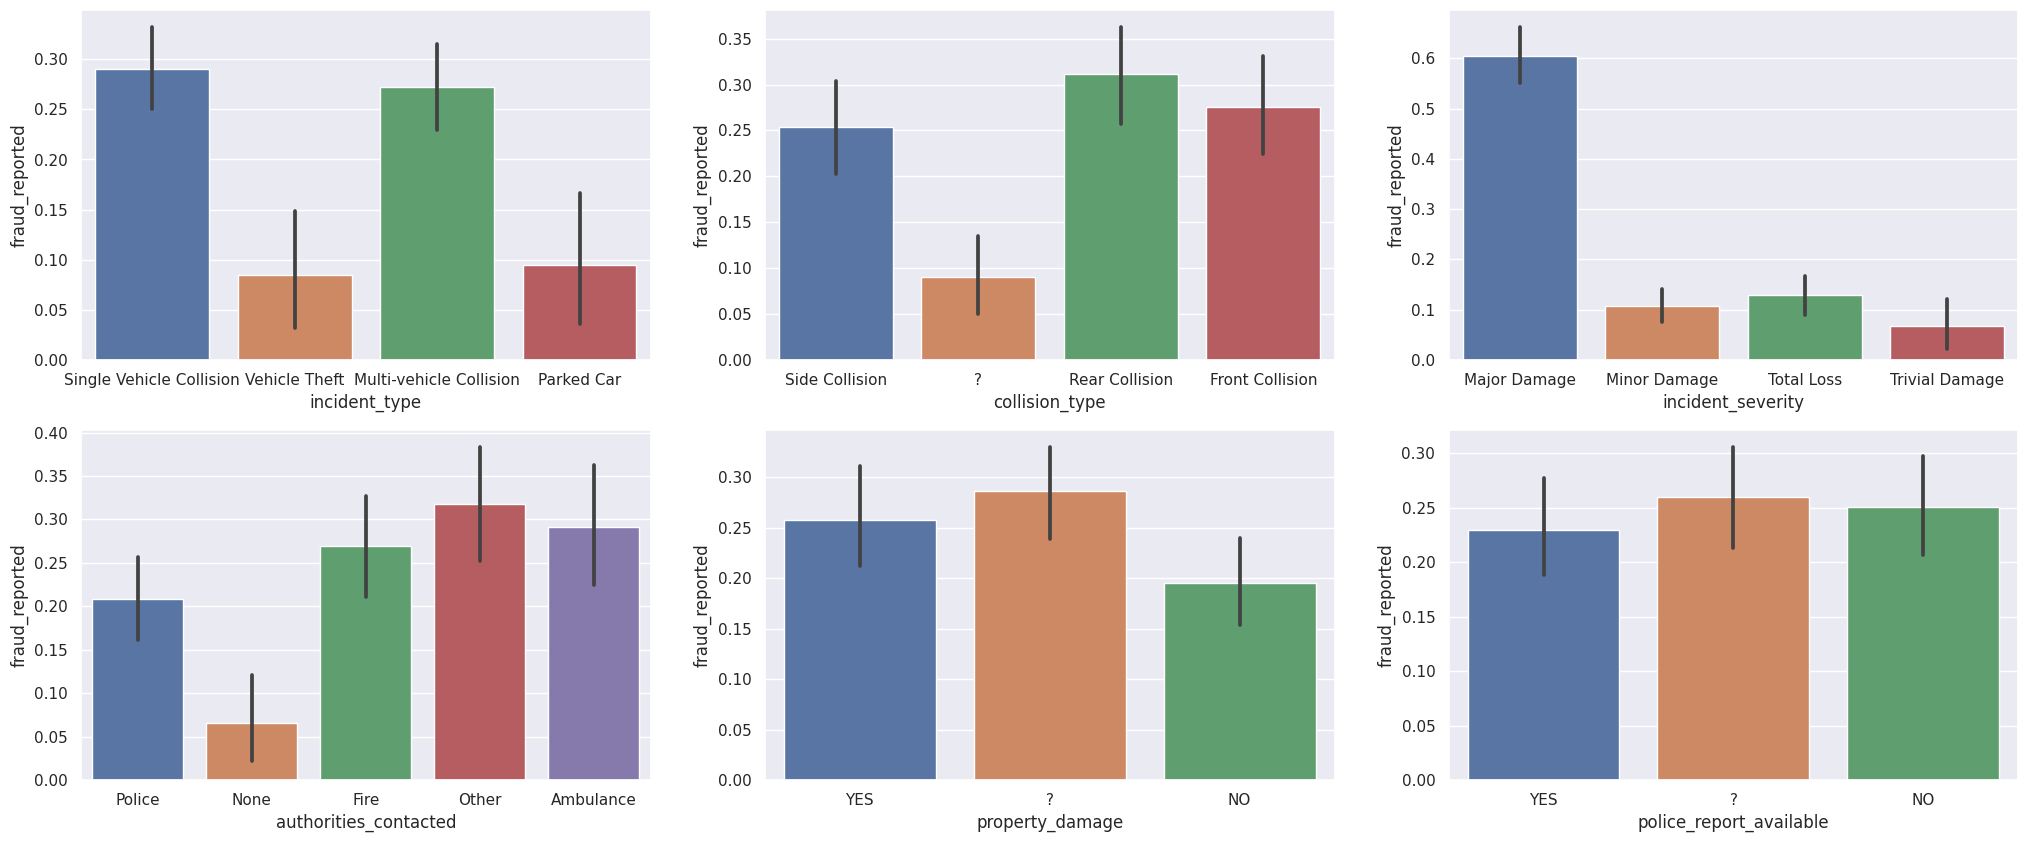

In [ ]:
cat_list = ['incident_type','collision_type','incident_severity',
            'authorities_contacted','property_damage','police_report_available']
fig = plt.figure(figsize=(25,10))

for i in range(len(cat_list)):
  sub = fig.add_subplot(2,3,i+1)
  chart = sns.barplot(data = df,x=cat_list[i],y='fraud_reported')

**Interprétation**

On remarque à partir des graphique que les features susceptibles d'influencer la prédiction de fraude sont : incident_type, incident_severity et authorities_contacted.

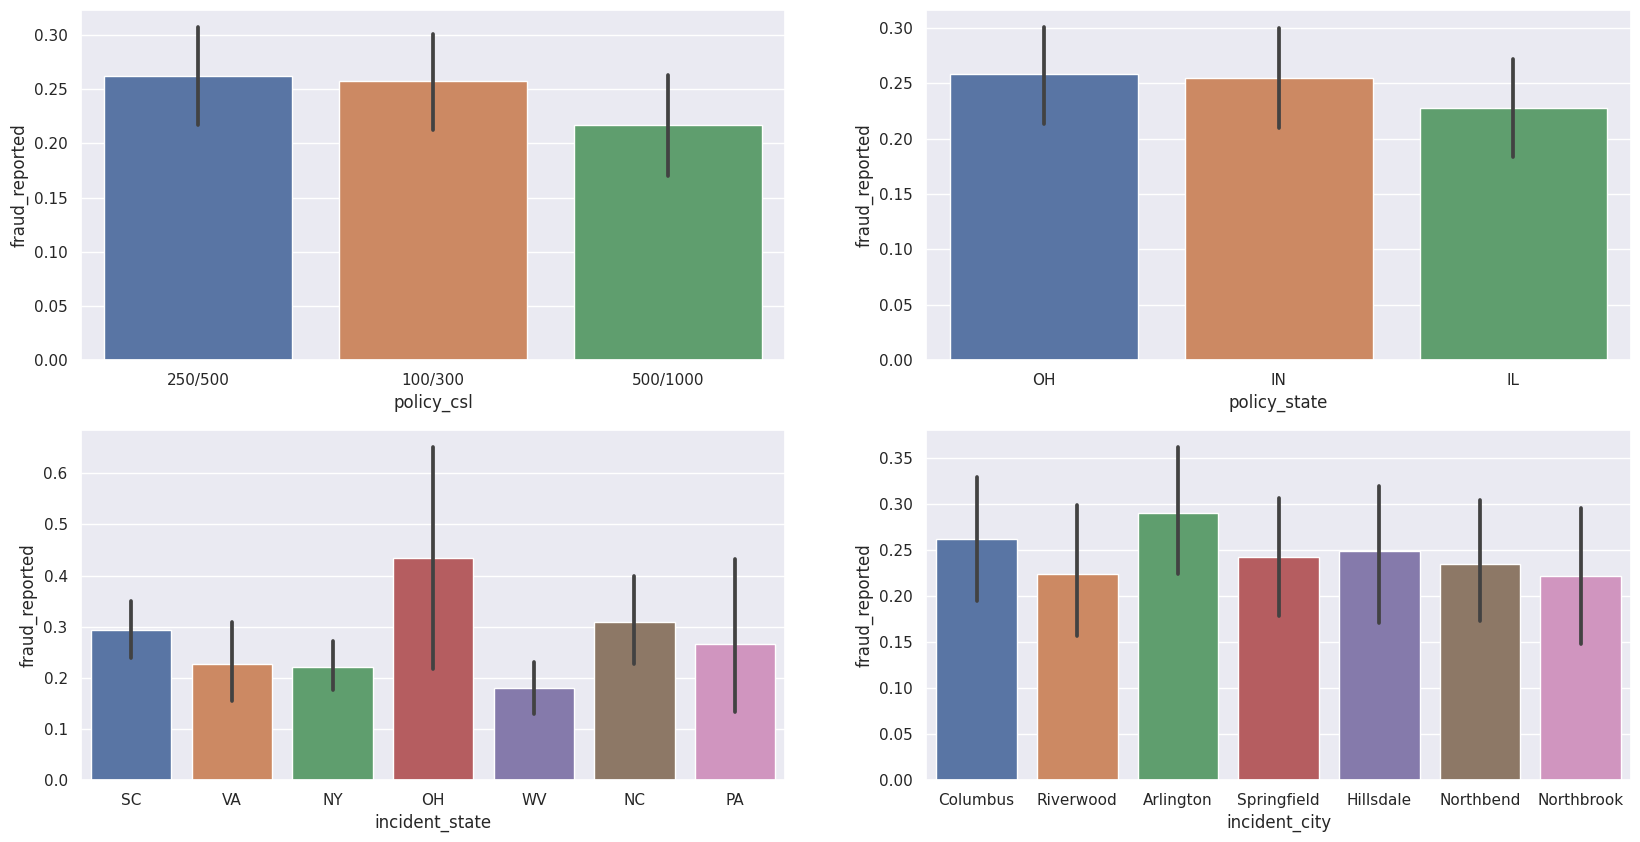

In [ ]:
cat_list = ['policy_csl','policy_state','incident_state','incident_city']
fig = plt.figure(figsize=(20,10))

for i in range(len(cat_list)):
  sub = fig.add_subplot(2,2,i+1)
  chart = sns.barplot(data = df,x=cat_list[i],y='fraud_reported')

**Interprétation**

On remarque à partir des graphique que ces features n'ont pas grande influence sur la prédiction de fraude.

## Visualisation des données numériques

In [ ]:
info(df)[info(df)['types']!='object']

,columns,non-null_values,types,unique_values
0,months_as_customer,1000,int64,391
1,age,1000,int64,46
2,policy_number,1000,int64,1000
6,policy_deductable,1000,int64,3
7,policy_annual_premium,1000,float64,991
8,umbrella_limit,1000,int64,11
9,insured_zip,1000,int64,995
15,capital-gains,1000,int64,338
16,capital-loss,1000,int64,354
25,incident_hour_of_the_day,1000,int64,24


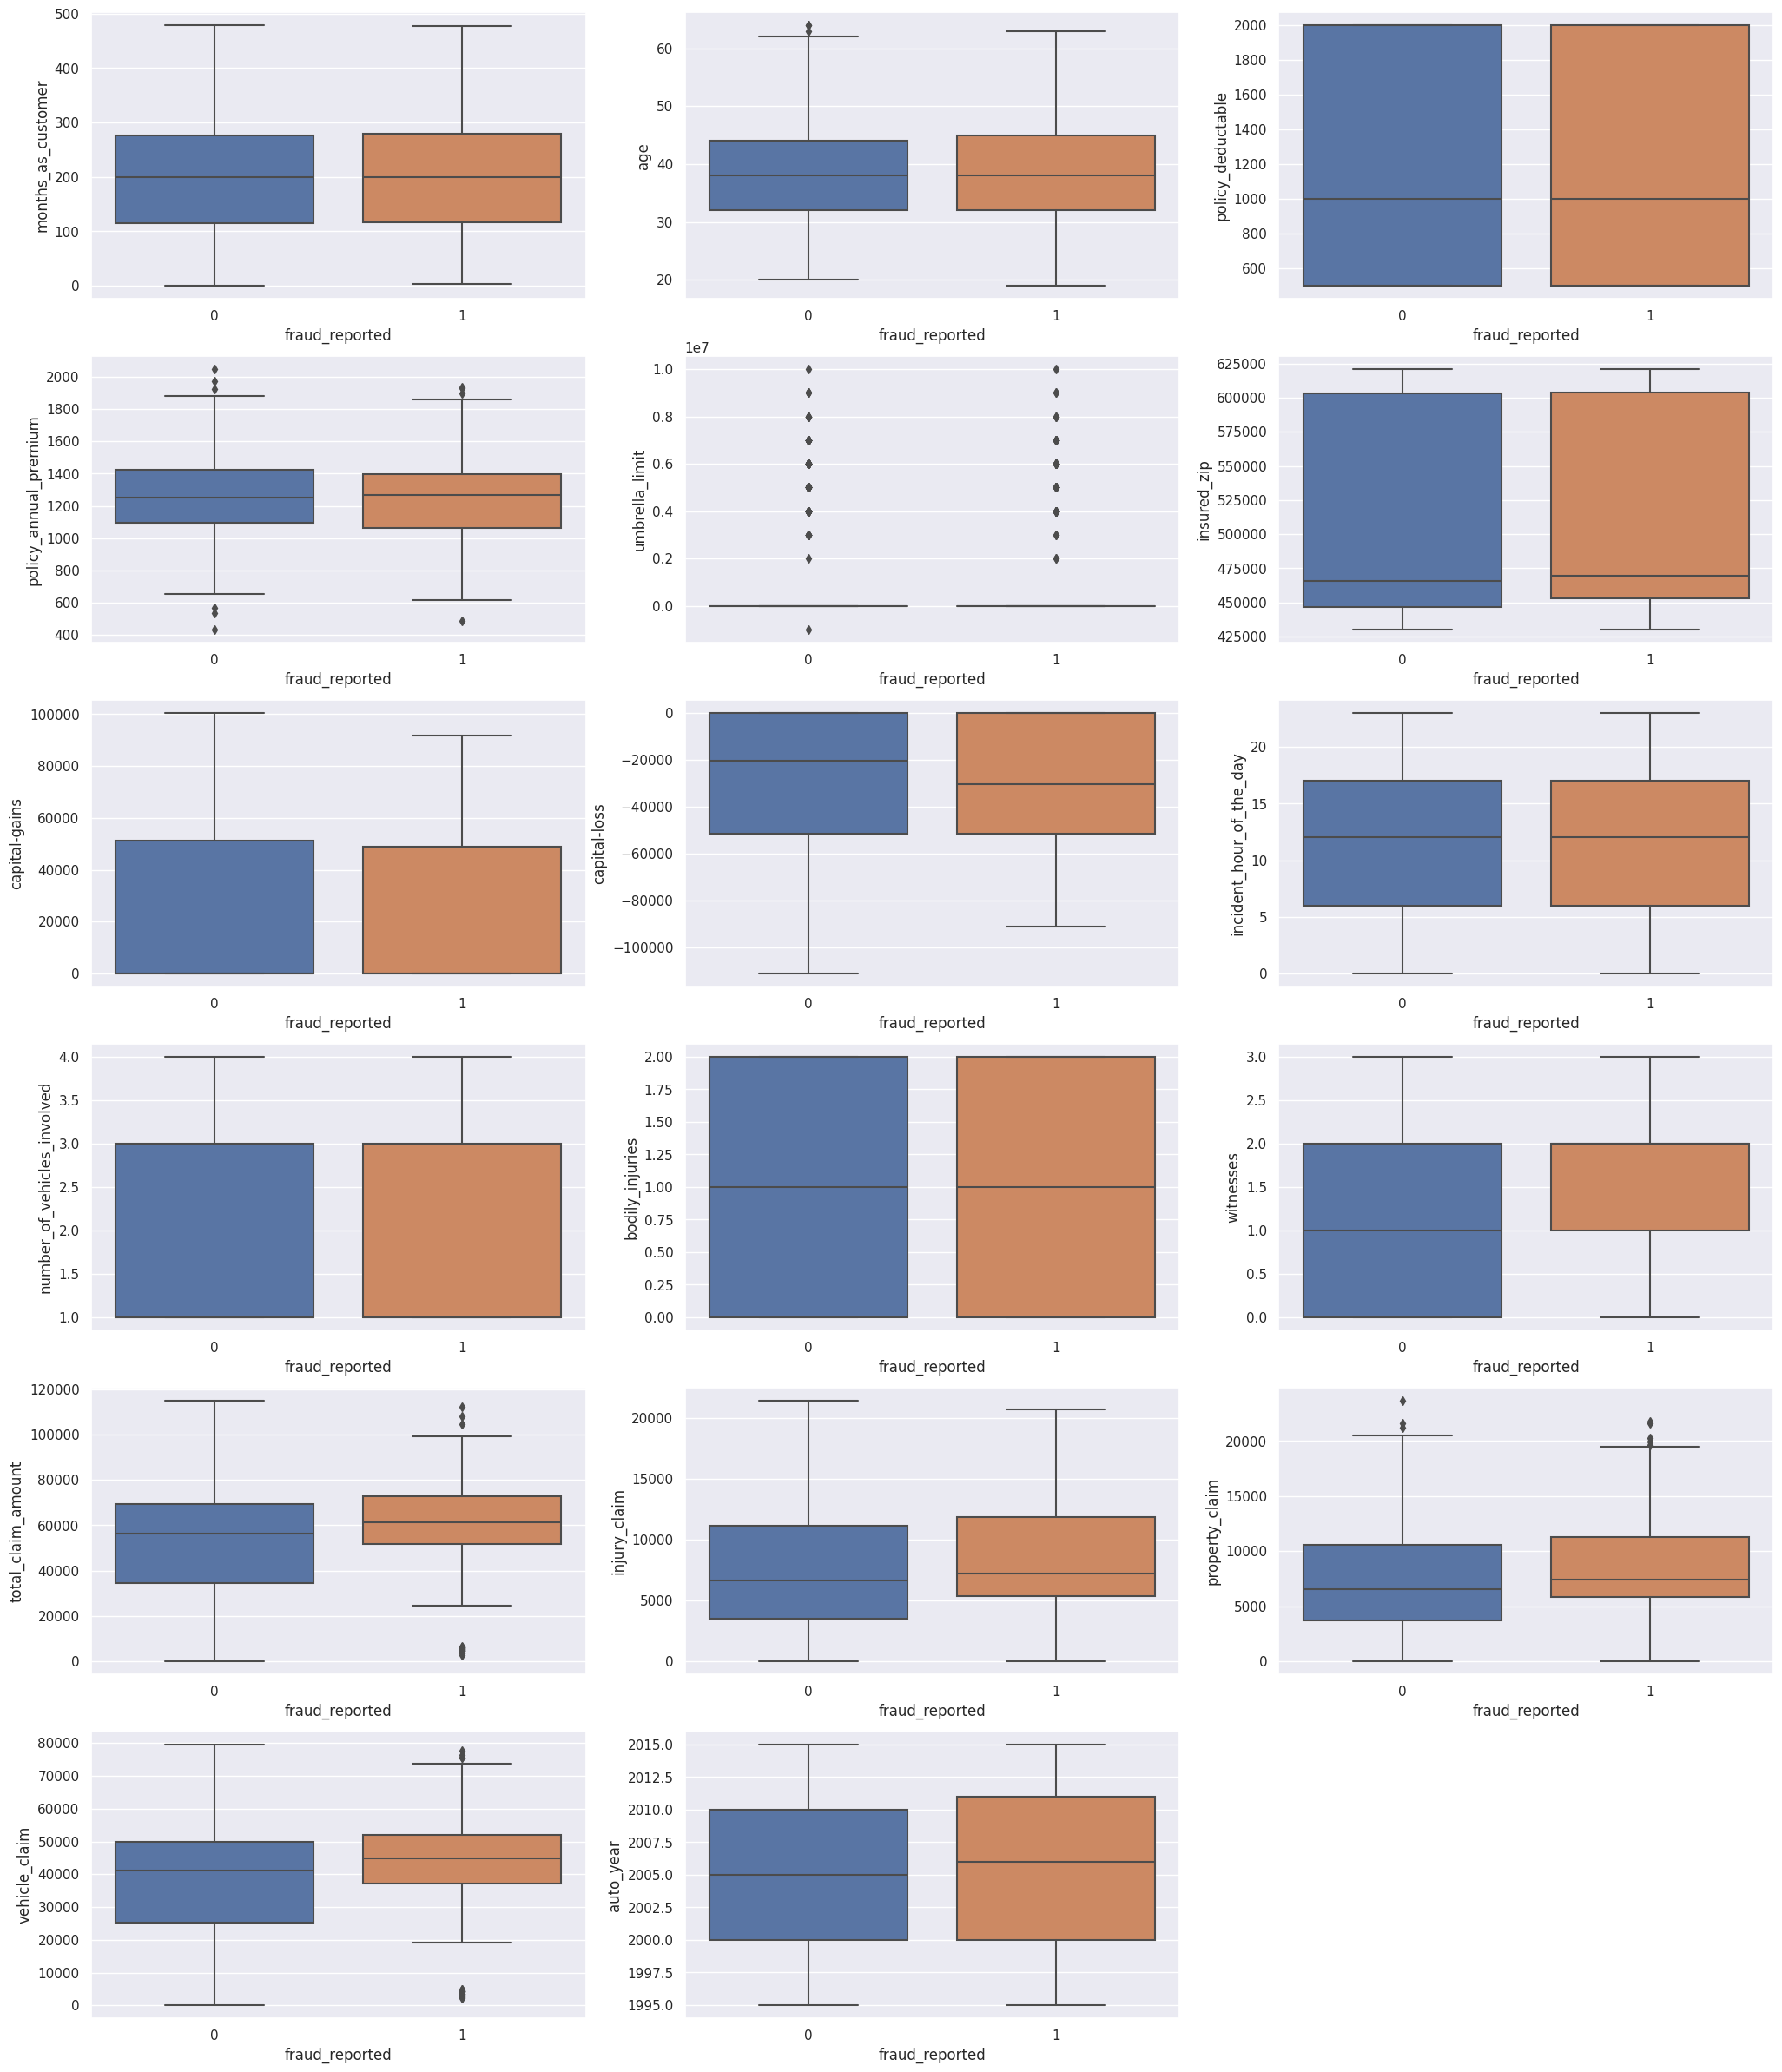

In [ ]:
num_list = ['months_as_customer','age','policy_deductable',
 'policy_annual_premium','umbrella_limit','insured_zip',
 'capital-gains', 'capital-loss', 'incident_hour_of_the_day',
 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses',
 'total_claim_amount', 'injury_claim', 'property_claim',
 'vehicle_claim', 'auto_year']
fig = plt.figure(figsize=(25,30))

for i in range(len(num_list)):
  sub = fig.add_subplot(6,3, i+1)
  sns.boxplot(x='fraud_reported', y = num_list[i], data = df)

**Interprétation**

On remarque à partir des graphique que les features susceptibles d'influencer la prédiction de fraude sont : total_claim_amount, property_claim et vehicle_claim.

# Pre-processing

## Remplacer les valeurs nulles

In [ ]:
import numpy as np
df = df.replace("?", np.nan)
info(df)

,columns,non-null_values,types,unique_values
0,months_as_customer,1000,int64,391
1,age,1000,int64,46
2,policy_number,1000,int64,1000
3,policy_bind_date,1000,object,951
4,policy_state,1000,object,3
5,policy_csl,1000,object,3
6,policy_deductable,1000,int64,3
7,policy_annual_premium,1000,float64,991
8,umbrella_limit,1000,int64,11
9,insured_zip,1000,int64,995


In [ ]:
df['collision_type']= df['collision_type'].fillna(method='ffill')
df['property_damage']= df['property_damage'].fillna(method='ffill')
df['police_report_available']= df['police_report_available'].fillna(method='ffill')

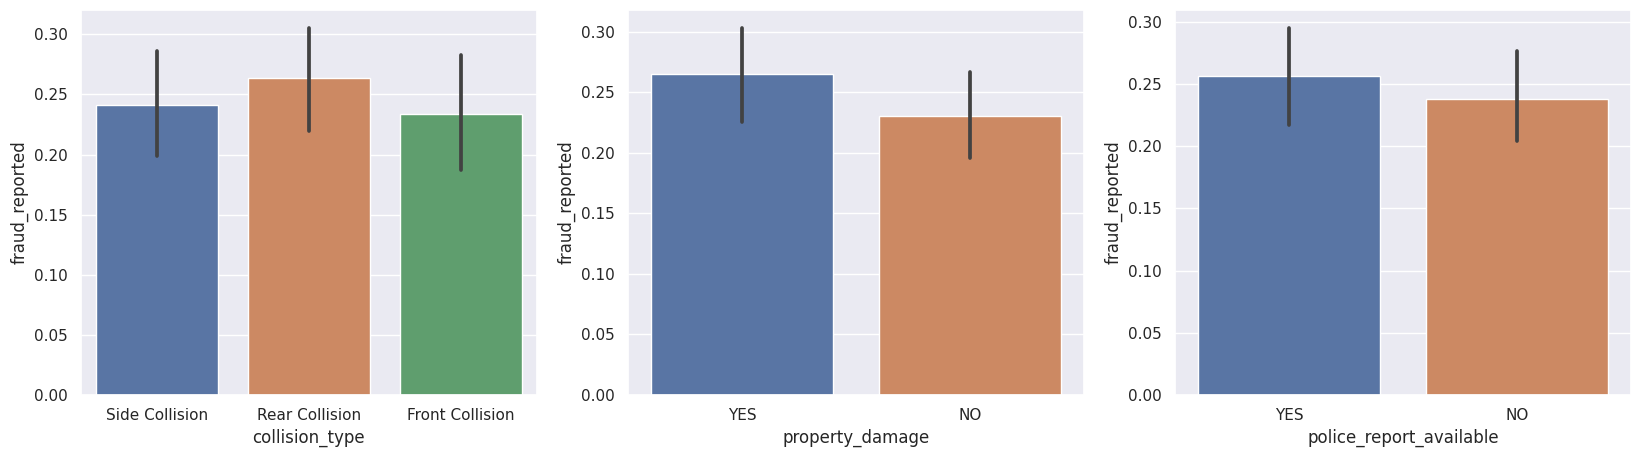

In [ ]:
clist = ['collision_type','property_damage','police_report_available']
fig = plt.figure(figsize=(20,5))

for i in range(len(clist)):
  sub = fig.add_subplot(1,3,i+1)
  chart = sns.barplot(data = df,x=clist[i],y='fraud_reported')

**Interprétation**

On remarque pour les 3 graphiques que la distribution ne change pas vraiment lors du remplacement des valeurs nulles.

## Supprimer les colonnes inutiles à notre analyse

In [ ]:
df.drop(['_c39','incident_location','insured_education_level','insured_relationship',
         'insured_occupation','collision_type','police_report_available',
         'property_damage','incident_city','policy_csl','policy_state',
         'auto_make','auto_model'], axis=1, inplace=True)
df.drop(['policy_number','policy_deductable','umbrella_limit','insured_zip','bodily_injuries'], axis=1, inplace=True)

## Encodage et génération de nouvelles features

In [ ]:
df['days_pol_bind_incid'] = (pd.to_datetime(df['incident_date'], format='%Y-%M-%d')- pd.to_datetime(df['policy_bind_date'], format='%Y-%M-%d')) / np.timedelta64(1, 'D')
df.drop(['policy_bind_date','incident_date'], axis=1, inplace=True)

**Encodage des données qualitatives**

In [ ]:
df['insured_sex'].value_counts()

FEMALE    537
MALE      463
Name: insured_sex, dtype: int64

In [ ]:
insured_sex = {
    "MALE":0,
    "FEMALE":1
}
df['insured_sex'] = df['insured_sex'].map(insured_sex)
df['insured_sex'].value_counts()

1    537
0    463
Name: insured_sex, dtype: int64

In [ ]:
df['auth_contact'] = [0 if x== 'None' else 1 for x in df['authorities_contacted']]

In [ ]:
list_col = info(df)[info(df)['types']=='object']['columns'].tolist()

for c in list_col:
  dummies = pd.get_dummies(df[c], prefix=c)
  df = df.join(dummies)

df.drop(list_col, axis=1, inplace=True)
df.head(10)

,months_as_customer,age,policy_annual_premium,insured_sex,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,witnesses,total_claim_amount,...,authorities_contacted_None,authorities_contacted_Other,authorities_contacted_Police,incident_state_NC,incident_state_NY,incident_state_OH,incident_state_PA,incident_state_SC,incident_state_VA,incident_state_WV
0,328,48,1406.91,0,53300,0,5,1,2,71610,...,0,0,1,0,0,0,0,1,0,0
1,228,42,1197.22,0,0,0,8,1,0,5070,...,0,0,1,0,0,0,0,0,1,0
2,134,29,1413.14,1,35100,0,7,3,3,34650,...,0,0,1,0,1,0,0,0,0,0
3,256,41,1415.74,1,48900,-62400,5,1,2,63400,...,0,0,1,0,0,1,0,0,0,0
4,228,44,1583.91,0,66000,-46000,20,1,1,6500,...,1,0,0,0,1,0,0,0,0,0
5,256,39,1351.10,1,0,0,19,3,2,64100,...,0,0,0,0,0,0,0,1,0,0
6,137,34,1333.35,0,0,-77000,0,3,0,78650,...,0,0,1,0,1,0,0,0,0,0
7,165,37,1137.03,0,0,0,23,3,2,51590,...,0,0,1,0,0,0,0,0,1,0
8,27,33,1442.99,1,0,0,21,1,1,27700,...,0,0,1,0,0,0,0,0,0,1
9,212,42,1315.68,0,0,-39300,14,1,1,42300,...,0,1,0,1,0,0,0,0,0,0


## Gestion des valeurs aberrantes

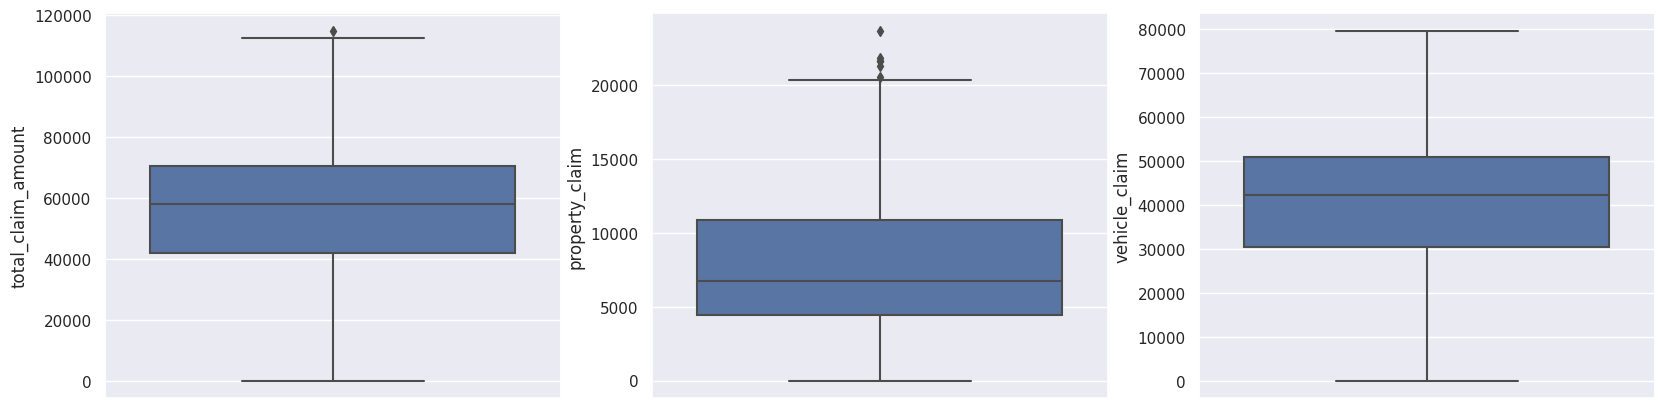

In [ ]:
list_col = ['total_claim_amount','property_claim','vehicle_claim']
fig = plt.figure(figsize=(20,5))

for i in range(len(list_col)):
  sub = fig.add_subplot(1,3, i+1)
  sns.boxplot(y = list_col[i], data = df)

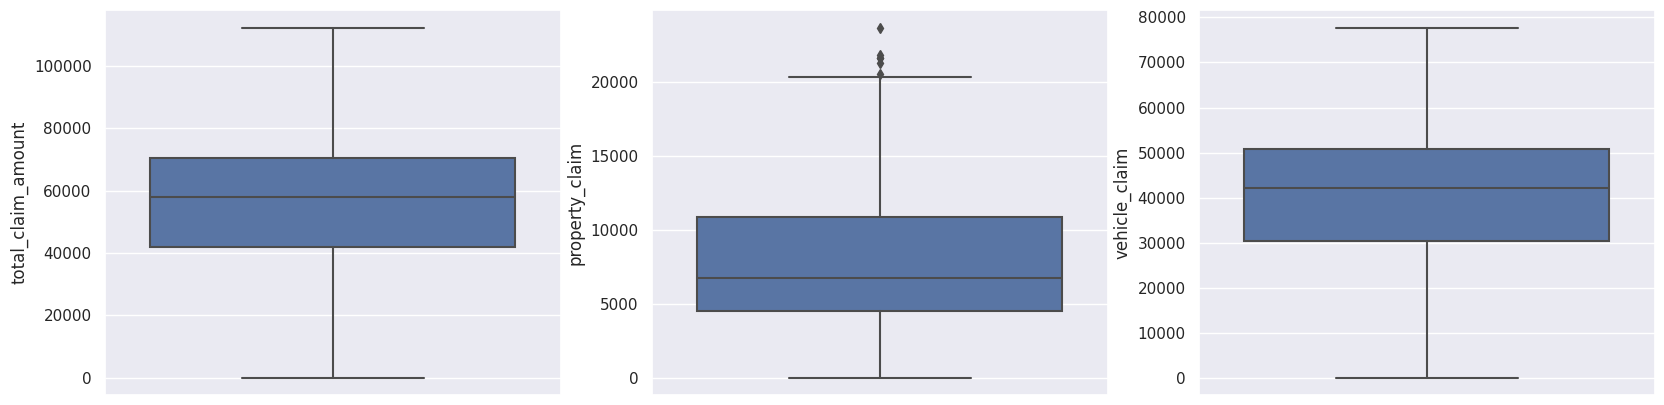

In [ ]:
N = 1.5
for l in list_col:
  q1= np.percentile(df[l],25)
  q3 = np.percentile(df[l],75)
  upper_o = np.where(df[l] > q3 + N*(q3-q1))
  lower_o = np.where(df[l] < q1 - N*(q3-q1))
  df.drop(upper_o[0],inplace=True)
  df.drop(lower_o[0],inplace=True)

fig = plt.figure(figsize=(20,5))

for i in range(len(list_col)):
  sub = fig.add_subplot(1,3, i+1)
  sns.boxplot(y = list_col[i], data = df)

# Matrice de corrélation

In [ ]:
coef = df.corr()
coef.style.background_gradient(cmap='coolwarm')

,months_as_customer,age,policy_annual_premium,insured_sex,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,fraud_reported,days_pol_bind_incid,auth_contact,insured_hobbies_base-jumping,insured_hobbies_basketball,insured_hobbies_board-games,insured_hobbies_bungie-jumping,insured_hobbies_camping,insured_hobbies_chess,insured_hobbies_cross-fit,insured_hobbies_dancing,insured_hobbies_exercise,insured_hobbies_golf,insured_hobbies_hiking,insured_hobbies_kayaking,insured_hobbies_movies,insured_hobbies_paintball,insured_hobbies_polo,insured_hobbies_reading,insured_hobbies_skydiving,insured_hobbies_sleeping,insured_hobbies_video-games,insured_hobbies_yachting,incident_type_Multi-vehicle Collision,incident_type_Parked Car,incident_type_Single Vehicle Collision,incident_type_Vehicle Theft,incident_severity_Major Damage,incident_severity_Minor Damage,incident_severity_Total Loss,incident_severity_Trivial Damage,authorities_contacted_Ambulance,authorities_contacted_Fire,authorities_contacted_None,authorities_contacted_Other,authorities_contacted_Police,incident_state_NC,incident_state_NY,incident_state_OH,incident_state_PA,incident_state_SC,incident_state_VA,incident_state_WV
months_as_customer,1.000000,0.921387,0.005852,-0.067179,0.006758,0.025486,0.071177,0.015119,0.060620,0.055307,0.060009,0.027550,0.054718,-0.002520,0.024198,0.046108,0.027304,-0.045753,0.033148,0.055966,0.086549,0.027740,0.062168,0.018031,-0.006067,0.013897,-0.083185,-0.015749,0.012930,-0.001566,0.032670,-0.055969,0.010113,-0.019669,-0.012179,-0.053718,-0.057867,0.018493,-0.028280,0.014747,-0.029419,0.024179,0.035108,-0.025317,-0.057119,-0.025323,0.032354,-0.027304,-0.001926,0.011266,-0.007699,0.025404,-0.011939,-0.044437,-0.018791,-0.019481,0.035681
age,0.921387,1.000000,0.015695,-0.080389,-0.007254,0.013633,0.087205,0.021846,0.054660,0.060563,0.068715,0.051347,0.053727,-0.001469,0.016100,0.034064,0.027485,-0.044152,0.045539,0.044584,0.077382,0.003951,0.072925,0.017372,-0.002797,0.010197,-0.073357,-0.008508,0.013710,-0.014895,0.022565,-0.046225,-0.000403,-0.018872,0.013141,-0.049264,-0.052681,0.019511,-0.013967,0.013371,-0.042348,0.029195,0.024224,-0.020857,-0.053757,-0.019007,0.017548,-0.027485,-0.003301,0.020632,0.006834,0.014438,-0.011331,-0.045821,-0.026975,-0.011219,0.038998
policy_annual_premium,0.005852,0.015695,1.000000,-0.040076,-0.013229,0.020438,0.002366,-0.044511,0.006053,0.009944,-0.018074,-0.010129,0.021160,-0.048791,-0.013916,-0.000900,0.007777,0.020233,0.043899,0.018230,0.013176,-0.024547,-0.033971,-0.002010,0.025117,0.042055,-0.047889,0.019321,-0.013429,-0.007608,-0.083770,0.031603,-0.045945,0.023397,0.019173,-0.026970,0.049779,-0.046332,-0.037079,0.059625,0.013080,-0.004899,0.011040,0.014294,-0.033432,0.028734,0.038270,-0.007777,-0.014071,-0.042877,-0.028932,-0.007882,-0.028760,-0.012952,-0.032833,0.054573,0.039098
insured_sex,-0.067179,-0.080389,-0.040076,1.000000,0.024063,0.021768,-0.019719,-0.017332,-0.040292,0.023865,0.000067,0.013417,0.029902,0.029171,-0.026713,-0.031423,0.045681,-0.033869,-0.045881,-0.015036,0.001200,-0.033811,0.009739,0.003677,0.050303,0.031291,-0.002364,-0.006617,0.037439,-0.002911,0.057338,-0.033921,-0.021507,0.041463,-0.008770,0.003110,-0.038304,-0.007529,0.016673,0.025365,-0.045709,-0.025496,-0.000745,0.025879,0.000516,0.002783,0.056310,-0.045681,-0.058461,0.025827,-0.007275,-0.012172,-0.084120,-0.017569,0.045932,0.031491,-0.015596
capital-gains,0.006758,-0.007254,-0.013229,0.024063,1.000000,-0.042808,-0.016226,0.061699,-0.016942,0.012835,0.023242,-0.003919,0.012924,0.031204,-0.021372,-0.045882,-0.039991,0.022350,-0.001722,-0.022353,-0.027430,-0.035178,-0.036814,-0.019675,-0.040824,0.008186,0.016866,0.059107,-0.078671,0.034087,0.090439,-0.040167,0.004317,0.000310,-0.024207,0.069874,0.005418,0.047512,-0.014538,-0.025814,-0.023238,-0.018836,0.030811,0.014292,-0.044737,0.035909,-0.007460,0.039991,-0.003801,-0.046231,

**Affichage des features dont la corrélation en valeur absolue avec fraud_reported est > 0.09**

In [ ]:
coef[abs(coef['fraud_reported'])> 0.09].fraud_reported

total_claim_amount                  0.165454
injury_claim                        0.091163
property_claim                      0.140146
vehicle_claim                       0.171795
fraud_reported                      1.000000
auth_contact                        0.131824
insured_hobbies_chess               0.300167
insured_hobbies_cross-fit           0.218410
incident_type_Parked Car           -0.105120
incident_type_Vehicle Theft        -0.121215
incident_severity_Major Damage      0.513116
incident_severity_Minor Damage     -0.240822
incident_severity_Total Loss       -0.172429
incident_severity_Trivial Damage   -0.130456
authorities_contacted_None         -0.131824
Name: fraud_reported, dtype: float64

# Machine Learning (Supervised - Classification)

**Création de 3 vecteurs X:**

* x_c pour les features fortement corrélées avec fraud_reported (target)
* x_p pour les features "soeurs" des features fortement corrélées avec fraud_reported (target) ie toutes les feautures générées par une même colonne qu'une feature fortement corrélée
* x pour la totalité des features

Le but ici, est de savoir s'il est nécessaire de prendre d'autres features que les features fortement corrélées pour avoir une meilleure classification.

In [ ]:
y = df['fraud_reported']

# x contains highly correlated features
x_coef = coef[abs(coef['fraud_reported'])> 0.09].fraud_reported.index.to_list()
x_coef.remove('fraud_reported')
x_coef.remove('authorities_contacted_None')
x_c = df[x_coef]

# x contains highly correlated features and their sisters
x_ = list(set(x_coef + [k for k in df.columns if 'insured_hobbies_' in k or 'incident_severity_' in k or 'incident_type_' in k]))
x_p = df[x_]

# x all
x = df.drop(['fraud_reported'], axis=1)

**Standardisation des vecteurs X**

In [ ]:
from sklearn.preprocessing import StandardScaler
SC = StandardScaler()
x_scaled = SC.fit_transform(x)
x_p_scaled = SC.fit_transform(x_p)
x_c_scaled = SC.fit_transform(x_c)

**Importation des librairies nécessaires**

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

**Création d'une liste de dictionnaires **

Chaque dictionnaire contient le nom du modèle, la fonction classifier à appeler, les paramètres à tester pour trouver la meilleure accuracy.

In [ ]:
model = [
    {
        'model': 'Logistic Regression',
        'classifier': [LogisticRegression()],
        'parameters' : {
            "penalty":["l1","l2","elasticnet"]
          }
    },
    {
        'model': 'SVM',
        'classifier': [SVC()],
        'parameters' : {
            "kernel":["linear", "poly", "rbf", "sigmoid"],
            'degree':[3,4,5]
          }
    },
    {
        'model': 'KNN',
        'classifier': [KNeighborsClassifier()],
        'parameters' : {
            "n_neighbors":np.arange(1,30),
            'metric':['euclidean',"manhattan",'chebyshev','minkowski']
          }
    },
    {
        'model': 'Decision Tree',
        'classifier': [DecisionTreeClassifier()],
        'parameters' : {
            "max_depth":range(5,15),
            "max_leaf_nodes":range(5,30),
            "min_samples_leaf":range(3,10)
          }
    },
    {
        'model': 'Random Forest',
        'classifier': [RandomForestClassifier()],
        'parameters' : {
            "n_estimators":range(2,20),
            "criterion" : ["gini", "entropy", "log_loss"],
            "max_depth":range(5,15)
          }
    },
    {
        'model': 'XGBoost',
        'classifier': [xgb.XGBClassifier()],
        'parameters' : {
            "n_estimators":range(2,20),
            "max_depth":range(5,15),
            "max_leaves":range(5,30)
          }
    }
]

Dans les 3 cellules qui suivent, j'ai crée une boucle pour chaque vecteur X. La boucle parcoure les modèles de la liste précédemment créée et applique un Grid Search sur le modèle avec les paramètres spécifiés dans le dictionnaire.

J'alimente ensuite une liste avec un dictionnaire pour chaque modèle qui contient le nom du modèle, les meilleurs paramètres et le meilleur score obtenus par grid search et le score d'une cross validation à 5 sets.

In [ ]:
from sklearn.model_selection import GridSearchCV

X_grid_search_results = []
for elm in range(len(model)):
  grid_search = GridSearchCV(model[elm]['classifier'][0], model[elm]['parameters'])
  gsf = grid_search.fit(x_scaled, y)
  prediction = gsf.predict(x_scaled)
  X_grid_search_results.append(
      {
          'model': model[elm]['model'],
          'params': grid_search.best_params_,
          'grid_search_score': grid_search.best_score_,
          'cross_val_score': cross_val_score(estimator=model[elm]['classifier'][0], X=x_scaled, y=y, cv=5).mean()
      }
  )
  # 26 minutes d'execution

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:378: FitFailedWarning: 
10 fits failed out of a total of 15.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py", line 1162, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py", line 54, in _check_solver
    raise ValueError(
ValueError: Solver

In [ ]:
Xp_grid_search_results = []
for elm in range(len(model)):
  grid_search = GridSearchCV(model[elm]['classifier'][0], model[elm]['parameters'])
  gsf = grid_search.fit(x_p_scaled, y)
  prediction = gsf.predict(x_p_scaled)
  Xp_grid_search_results.append(
      {
          'model': model[elm]['model'],
          'params': grid_search.best_params_,
          'grid_search_score': grid_search.best_score_,
          'cross_val_score': cross_val_score(estimator=model[elm]['classifier'][0], X=x_p_scaled, y=y, cv=5).mean()
      }
  )
# 17 minutes d'execution

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:378: FitFailedWarning: 
10 fits failed out of a total of 15.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py", line 1162, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py", line 54, in _check_solver
    raise ValueError(
ValueError: Solver

In [ ]:
Xc_grid_search_results = []
for elm in range(len(model)):
  grid_search = GridSearchCV(model[elm]['classifier'][0], model[elm]['parameters'])
  gsf = grid_search.fit(x_c_scaled, y)
  prediction = gsf.predict(x_c_scaled)
  Xc_grid_search_results.append(
      {
          'model': model[elm]['model'],
          'params': grid_search.best_params_,
          'grid_search_score': grid_search.best_score_,
          'cross_val_score': cross_val_score(estimator=model[elm]['classifier'][0], X=x_c_scaled, y=y, cv=5).mean()
      }
  )
#  13 minutes d'execution

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:378: FitFailedWarning: 
10 fits failed out of a total of 15.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py", line 1162, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py", line 54, in _check_solver
    raise ValueError(
ValueError: Solver

**J'alimente un dataframe avec les liste de disctionnaire pour pouvoir comparer les résultats plus facilement**

In [ ]:
df_x = pd.DataFrame.from_dict(X_grid_search_results)
df_x['X_vector'] = ['x' for i in df_x['model']]
df_xp = pd.DataFrame.from_dict(Xp_grid_search_results)
df_xp['X_vector'] = ['x_p' for i in df_x['model']]
df_xc = pd.DataFrame.from_dict(Xc_grid_search_results)
df_xc['X_vector'] = ['x_c' for i in df_x['model']]
dff = pd.concat([df_x, df_xp, df_xc])
dff

,model,params,grid_search_score,cross_val_score,X_vector
0,Logistic Regression,{'penalty': 'l2'},0.852845,0.852845,x
1,SVM,"{'degree': 3, 'kernel': 'sigmoid'}",0.859916,0.850845,x
2,KNN,"{'metric': 'euclidean', 'n_neighbors': 11}",0.804462,0.792361,x
3,Decision Tree,"{'max_depth': 5, 'max_leaf_nodes': 5, 'min_sam...",0.855880,0.773209,x
4,Random Forest,"{'criterion': 'log_loss', 'max_depth': 14, 'n_...",0.819598,0.803462,x
5,XGBoost,"{'max_depth': 5, 'max_leaves': 5, 'n_estimator...",0.839775,0.811502,x
0,Logistic Regression,{'penalty': 'l2'},0.843785,0.843785,x_p
1,SVM,"{'degree': 3, 'kernel': 'linear'}",0.847800,0.846800,x_p
2,KNN,"{'metric': 'euclidean', 'n_neighbors': 5}",0.846825,0.846825,x_p
3,Decision Tree,"{'max_depth': 5, 'max_leaf_nodes': 6, 'min_sam...",0.858906,0.769144,x_p


In [ ]:
dff[dff['cross_val_score']==dff['cross_val_score'].max()]

,model,params,grid_search_score,cross_val_score,X_vector
1,SVM,"{'degree': 3, 'kernel': 'linear'}",0.854865,0.854865,x_c


On conclut donc que l'algortime SVM (Support vector machines) donne les meilleurs résultats (un score de cross validation à 85,5%) en utilisant le vecteur x_c, contenant uniquement les feautures fortement corrélées à fraud_reported.